<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/Chronological_transformer_highpass_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [57]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [58]:
!ls "/content/drive/My Drive/ASCE_IASC"

figures					random_window_split_seed42.csv
MAT_data				Results
processed_zero_mean			txt_all_15_sensors
random_block_assignment_45s_seed42.csv	txt_selected_sensors


In [59]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 15


In [60]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 15) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 15) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 15) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 15) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 15) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 15) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 15) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 15) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 15) | fs: 200.0 Hz | label: 8
description:                                                0
0   Base West side - EPI sensor X direction (N+)
1      Base Center - EPI sensor Y direction (W+)
2   Base East side - EPI sensor X direction (N+)
3    1st Floor - N/S EPI Sensor at West end (N+)
4      1st Floor - E/W FBA Sensor at Center (W+)
5    1st Floor - N/S FBA Sensor at East end (N+)
6    2nd Floor - N/S FBA Sensor at West end (N+)
7      2nd Floor - E/W EPI Sensor at Center (W+)
8    2nd Floor - N/S EPI Sensor at East end (N+)
9    3rd

In [61]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 15)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']


In [62]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [63]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [64]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm02a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm03a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm04a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm05a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm06a | Train: (26540, 15) | Validation: (8313, 15) | Test: (8315, 15)
shm07a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm08a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm09a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)


In [65]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001260,1.125002e-06
1,shm02a,0.001564,2.848653e-07
2,shm03a,0.000955,3.674356e-07
3,shm04a,0.001096,3.553501e-07
4,shm05a,0.001285,8.238489e-07
5,shm06a,0.001239,2.023264e-06
6,shm07a,0.001139,9.591543e-08
7,shm08a,0.001083,9.232525e-08
8,shm09a,0.001077,1.732560e-07


In [66]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']
Case shm01a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm02a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm03a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm04a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm05a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm06a: train=(26540, 12), val=(8313, 12), test=(8315, 12)
Case shm07a: train=(107200, 12), val=(35200, 12), test=(35200, 12)
Case shm08a: train=(107200, 12), val=(35200, 12), test=(35200, 12)
Case shm09a: train=(107200, 12), val=(35200, 12), test=(35200, 12)


In [67]:
# ============================================================
# Step 4: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8
train_concat = np.concatenate(
    [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


print("Combined Train shape:", train_concat.shape)
train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)


print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Combined Train shape: (524140, 12)
Train mean shape: (1, 12)
Train std shape: (1, 12)


In [68]:
train_norm = {}
val_norm = {}
test_norm = {}


for case_name in sorted(train_selected.keys()):

    train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


print("Normalization completed.")

Normalization completed.


In [69]:
train_norm_concat = np.concatenate(
    [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

normalized_train_mean = train_norm_concat.mean(axis=0)
normalized_train_std = train_norm_concat.std(axis=0)

print("Train mean after normalization:")
print(np.round(normalized_train_mean,5))

print("\nTrain std after normalization:")
print(np.round(normalized_train_std,5))

Train mean after normalization:
[-0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]

Train std after normalization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [70]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [71]:
def make_windows(split_data):

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [72]:
X_train, y_train, train_meta_df = make_windows(train_norm)

X_val, y_val, val_meta_df = make_windows(val_norm)

X_test, y_test, test_meta_df = make_windows(test_norm)

In [73]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 12)
X_val:   (325, 512, 12)
X_test:  (325, 512, 12)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [74]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [75]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 12)
X_val shape:   (325, 512, 12)
X_test shape:  (325, 512, 12)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


In [76]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# Reproducibility
# ----------------------------
SPLIT_SEED = None
MODEL_SEED = 2026

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(MODEL_SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


Tensor shapes:
X_train_tensor: torch.Size([1018, 512, 12])
y_train_tensor: torch.Size([1018])
X_val_tensor: torch.Size([325, 512, 12])
y_val_tensor: torch.Size([325])
X_test_tensor: torch.Size([325, 512, 12])
y_test_tensor: torch.Size([325])


In [77]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# برای تکرارپذیری Shuffle داده‌های Train
loader_generator = torch.Generator()
loader_generator.manual_seed(MODEL_SEED)


train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [78]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 1018
Number of val samples:   325
Number of test samples:  325

Number of train batches: 16
Number of val batches:   6
Number of test batches:  6

One train batch:
X_batch shape: torch.Size([64, 512, 12])
y_batch shape: torch.Size([64])
First 10 labels: tensor([7, 8, 6, 4, 7, 7, 8, 7, 1, 8])


In [79]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# Device
# ----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ----------------------------
# Learnable positional encoding
# ----------------------------
class LearnablePositionalEncoding(nn.Module):

    def __init__(self, seq_len, d_model):
        super().__init__()
        self.position = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.position,std=0.02)

    def forward(self, x):
        seq_len = x.shape[1]
        return x + self.position[:, :seq_len, :]

Device: cuda


In [80]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn

# --- Added these definitions to ensure the model parameters are defined ---
NUM_CLASSES = 9
SEQ_LEN = WINDOW_SIZE
INPUT_DIM = X_train_tensor.shape[2]
D_MODEL = 64
NUM_HEADS = 8
NUM_LAYERS = 2
DIM_FEEDFORWARD = 64
DROPOUT = 0.1
# --- End of added definitions ---

class TransformerTimeSeriesClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        num_classes,
        d_model=64,
        num_heads=8,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.10
    ):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model,num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

    def forward(self, x):
        # x shape: (batch, time, channels)

        x = self.input_projection(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer_encoder(x)
        x = self.final_norm(x)
        # Mean pooling over time
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits



In [81]:
set_seed(MODEL_SEED)
model = TransformerTimeSeriesClassifier(
    input_dim=INPUT_DIM,
    seq_len=SEQ_LEN,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

print(model)

# ----------------------------
# Count trainable parameters
# ----------------------------
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTrainable parameters:", count_trainable_parameters(model))


# ----------------------------
# Check one forward pass
# ----------------------------
for xb, yb in train_loader:
    xb = xb.to(device)

    logits = model(xb)

    print("\nInput batch shape:", xb.shape)
    print("Output logits shape:", logits.shape)

    break

TransformerTimeSeriesClassifier(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=9, bias=True)
)

Trainable parameters: 84745

Input batch shape:

/tmp/ipykernel_22012/3525986821.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


In [82]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 68 | weight: 1.6634
Scenario 2 | count: 68 | weight: 1.6634
Scenario 3 | count: 68 | weight: 1.6634
Scenario 4 | count: 68 | weight: 1.6634
Scenario 5 | count: 68 | weight: 1.6634
Scenario 6 | count: 51 | weight: 2.2179
Scenario 7 | count: 209 | weight: 0.5412
Scenario 8 | count: 209 | weight: 0.5412
Scenario 9 | count: 209 | weight: 0.5412


In [83]:
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0002


In [84]:
# Reset early stopping
best_val_macro_f1 = -1.0
best_val_loss = float("inf")

best_epoch = 0
best_model_state = None

patience_counter = 0
print("New experiment started")
print("Model_Seed:", MODEL_SEED)
print("Heads:", NUM_HEADS)
print("Dropout:", DROPOUT)

New experiment started
Model_Seed: 2026
Heads: 8
Dropout: 0.1


In [85]:
from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

transformer_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_transformer(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    transformer_history["epoch"].append(epoch)
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["train_macro_f1"].append(train_macro_f1)
    transformer_history["val_loss"].append(val_loss)
    transformer_history["val_acc"].append(val_acc)
    transformer_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch # Assign epoch here
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break



Epoch 001 | Train Loss: 2.1307 | Train Acc: 0.3821 | Train Macro-F1: 0.2080 | Val Loss: 1.9486 | Val Acc: 0.3077 | Val Macro-F1: 0.2076
Epoch 005 | Train Loss: 1.1916 | Train Acc: 0.7613 | Train Macro-F1: 0.7170 | Val Loss: 0.9904 | Val Acc: 0.8031 | Val Macro-F1: 0.7522
Epoch 010 | Train Loss: 0.4947 | Train Acc: 0.9587 | Train Macro-F1: 0.9716 | Val Loss: 0.3670 | Val Acc: 0.9785 | Val Macro-F1: 0.9830
Epoch 015 | Train Loss: 0.1226 | Train Acc: 0.9902 | Train Macro-F1: 0.9939 | Val Loss: 0.1047 | Val Acc: 0.9877 | Val Macro-F1: 0.9896
Epoch 020 | Train Loss: 0.0576 | Train Acc: 0.9951 | Train Macro-F1: 0.9965 | Val Loss: 0.0557 | Val Acc: 0.9908 | Val Macro-F1: 0.9951
Epoch 025 | Train Loss: 0.0350 | Train Acc: 0.9990 | Train Macro-F1: 0.9987 | Val Loss: 0.0374 | Val Acc: 0.9969 | Val Macro-F1: 0.9984
Epoch 030 | Train Loss: 0.0243 | Train Acc: 0.9990 | Train Macro-F1: 0.9987 | Val Loss: 0.0279 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Epoch 035 | Train Loss: 0.0178 | Train Acc: 1.00

In [86]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 26
Best validation Macro-F1: 1.0


In [87]:
# ============================================================
# Final evaluation control
# ============================================================

# Keep False during development/tuning.
# Set True only for final test evaluation.
RUN_TEST = False

In [88]:
# ============================================================
# Final evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def predict_with_model_transformer(
    model,
    data_loader,
    device="cpu"
):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits,dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_transformer(
    model,
    data_loader,
    split_name,
    device="cpu"
):

    y_true, y_pred = predict_with_model_transformer(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [89]:
model.eval()

transformer_train_results = final_evaluate_transformer(
    model,
    train_eval_loader,
    "TRAIN",
    device=device
)

transformer_val_results = final_evaluate_transformer(
    model,
    val_loader,
    "VALIDATION",
    device=device
)


===== TRAIN =====
Accuracy:    0.9990
Macro-F1:    0.9987
Weighted-F1: 0.9990

===== VALIDATION =====
Accuracy:    1.0000
Macro-F1:    1.0000
Weighted-F1: 1.0000


In [90]:
transformer_test_results = None

if RUN_TEST:

    transformer_test_results = final_evaluate_transformer(
        model,
        test_loader,
        "TEST",
        device=device
    )

else:

    print("\nTest evaluation skipped.")


Test evaluation skipped.


In [91]:
summary_rows = [
    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_train_results["split"],
        "accuracy":
            transformer_train_results["accuracy"],
        "macro_f1":
            transformer_train_results["macro_f1"],
        "weighted_f1":
            transformer_train_results["weighted_f1"]
    },

    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_val_results["split"],
        "accuracy":
            transformer_val_results["accuracy"],
        "macro_f1":
            transformer_val_results["macro_f1"],
        "weighted_f1":
            transformer_val_results["weighted_f1"]
    }
]

In [92]:
if RUN_TEST:

    summary_rows.append(
        {
            "model": "Raw Transformer",
            "preprocessing":
                "Butterworth high-pass + Train-based normalization",
            "selected_sensors":
                len(selected_sensor_names),
            "split":
                transformer_test_results["split"],
            "accuracy":
                transformer_test_results["accuracy"],
            "macro_f1":
                transformer_test_results["macro_f1"],
            "weighted_f1":
                transformer_test_results["weighted_f1"]
        }
    )

In [93]:
transformer_summary_results = pd.DataFrame(summary_rows)
display(transformer_summary_results)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw Transformer,Butterworth high-pass + Train-based normalization,12,TRAIN,0.999018,0.998655,0.999021
1,Raw Transformer,Butterworth high-pass + Train-based normalization,12,VALIDATION,1.000000,1.000000,1.000000


In [94]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================


if RUN_TEST:

    y_true_test = (
        transformer_test_results["y_true"]
    )

    y_pred_test = (
        transformer_test_results["y_pred"]
    )

    cm_transformer_test = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_transformer_test,
        display_labels=[
            f"S{i+1}"
            for i in range(NUM_CLASSES)
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        "Test Confusion Matrix"
    )

    plt.grid(False)
    plt.show()

In [95]:
# Chronological + High-pass + Raw Transformer + 12 sensors

# Test Accuracy    = 0.9892 ± 0.0018
# Test Macro-F1    = 0.9930 ± 0.0021
# Test Weighted-F1 = 0.9893 ± 0.0018

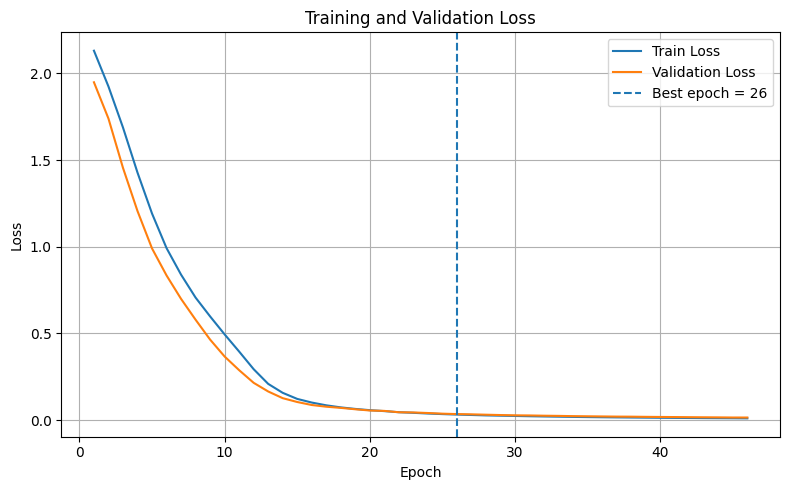

In [96]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

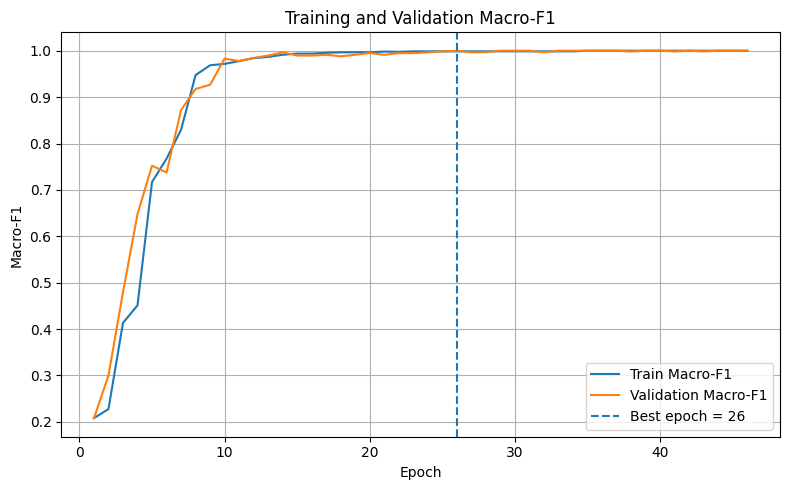

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Sensor Permutation Importance
## Phase 1 - Chronological Split - Validation Set

Global grouped sensor permutation importance.

Each complete sensor waveform (512 time samples) is permuted
across validation windows while the other sensors remain unchanged.

Primary metric:
Importance = Baseline Macro-F1 - Permuted Macro-F1

The test set is not used in this phase.

In [98]:
# ============================================================
# Sensor Permutation Importance - Basic checks
# ============================================================

print("Validation shape:", X_val.shape)
print("Validation labels:", y_val.shape)

print("\nSensor order:")
for i, sensor in enumerate(selected_sensor_names):
    print(i, sensor)

print(
    "\nBaseline Validation Macro-F1:",
    transformer_val_results["macro_f1"]
)

# Basic checks
assert X_val.ndim == 3
assert X_val.shape[1] == WINDOW_SIZE
assert X_val.shape[2] == len(selected_sensor_names)
assert len(X_val) == len(y_val)

print("\nBasic checks passed.")

Validation shape: (325, 512, 12)
Validation labels: (325,)

Sensor order:
0 DA04
1 DA05
2 DA06
3 DA07
4 DA08
5 DA09
6 DA10
7 DA11
8 DA12
9 DA13
10 DA14
11 DA15

Baseline Validation Macro-F1: 1.0

Basic checks passed.


In [99]:
# ============================================================
# Step 3 - Test one grouped sensor permutation
# ============================================================

PERMUTATION_SEED = 1001

sensor_name = "DA04"
sensor_idx = selected_sensor_names.index(sensor_name)

rng = np.random.default_rng(PERMUTATION_SEED)

# Random order of validation windows
perm_idx = rng.permutation(len(X_val))

# Copy validation data
X_val_perm = X_val.copy()

# Permute the COMPLETE waveform of DA04 across windows
X_val_perm[:, :, sensor_idx] = X_val[perm_idx, :, sensor_idx]

print("Sensor:", sensor_name)
print("Sensor index:", sensor_idx)
print("Original shape:", X_val.shape)
print("Permuted shape:", X_val_perm.shape)

print("\nFirst 10 permutation indices:")
print(perm_idx[:10])

Sensor: DA04
Sensor index: 0
Original shape: (325, 512, 12)
Permuted shape: (325, 512, 12)

First 10 permutation indices:
[109 172 284 124 320 280 111 273 141 186]


In [100]:
# ============================================================
# Checks
# ============================================================

# Other sensors must remain exactly unchanged
other_sensors = [
    i for i in range(X_val.shape[2])
    if i != sensor_idx
]

assert np.array_equal(
    X_val_perm[:, :, other_sensors],
    X_val[:, :, other_sensors]
)

# Example:
# waveform placed in validation window 0
# must be the COMPLETE DA04 waveform from window perm_idx[0]
source_window = perm_idx[0]

assert np.array_equal(
    X_val_perm[0, :, sensor_idx],
    X_val[source_window, :, sensor_idx]
)

print("\nWindow 0 received DA04 from window:", source_window)
print("DA04 waveform shape:", X_val_perm[0, :, sensor_idx].shape)
print("\nGrouped permutation check passed.")


Window 0 received DA04 from window: 109
DA04 waveform shape: (512,)

Grouped permutation check passed.


In [101]:
# ============================================================
# Step 4 - Evaluate one permuted sensor
# ============================================================

# Convert permuted validation array to tensor
X_val_perm_tensor = torch.from_numpy(X_val_perm.astype(np.float32, copy=False))

# Labels remain unchanged
perm_dataset = TensorDataset(X_val_perm_tensor,y_val_tensor)

perm_loader = DataLoader(perm_dataset,batch_size=BATCH_SIZE,shuffle=False)

# Evaluate the SAME trained Transformer
da04_perm_results = final_evaluate_transformer(
    model,
    perm_loader,
    "VALIDATION - DA04 PERMUTED",
    device=device
)

# Permutation importance
baseline_f1 = transformer_val_results["macro_f1"]
permuted_f1 = da04_perm_results["macro_f1"]

importance = baseline_f1 - permuted_f1

print("\nBaseline Macro-F1:", baseline_f1)
print("Permuted Macro-F1:", permuted_f1)
print("DA04 Importance:", importance)


===== VALIDATION - DA04 PERMUTED =====
Accuracy:    0.9169
Macro-F1:    0.9230
Weighted-F1: 0.9158

Baseline Macro-F1: 1.0
Permuted Macro-F1: 0.9230468780843819
DA04 Importance: 0.0769531219156181


In [102]:
# ============================================================
# Step 5 - Function for one sensor permutation
# ============================================================

import io
import contextlib

def evaluate_sensor_permutation(
    model,
    X_eval,
    y_eval_tensor,
    sensor_idx,
    permutation_seed,
    batch_size,
    device
):
    rng = np.random.default_rng(permutation_seed)
    perm_idx = rng.permutation(len(X_eval))

    X_perm = X_eval.copy()

    # Move the complete 512-sample waveform between windows
    X_perm[:, :, sensor_idx] = X_eval[perm_idx, :, sensor_idx]

    X_perm_tensor = torch.from_numpy(X_perm.astype(np.float32, copy=False))

    perm_dataset = TensorDataset(X_perm_tensor,y_eval_tensor)

    perm_loader = DataLoader(perm_dataset,batch_size=batch_size,shuffle=False)

    # Use exactly the same evaluation function,
    # but suppress repeated printed output
    with contextlib.redirect_stdout(io.StringIO()):
        results = final_evaluate_transformer(
            model,
            perm_loader,
            "PERMUTED",
            device=device
        )

    return results

In [103]:
# Reproduce the previous DA04 result

test_result = evaluate_sensor_permutation(
    model=model,
    X_eval=X_val,
    y_eval_tensor=y_val_tensor,
    sensor_idx=0,               # DA04
    permutation_seed=1001,
    batch_size=BATCH_SIZE,
    device=device
)

test_f1 = test_result["macro_f1"]
test_importance = (
    transformer_val_results["macro_f1"] - test_f1
)

print("DA04 permuted Macro-F1:", test_f1)
print("DA04 importance:", test_importance)

DA04 permuted Macro-F1: 0.9230468780843819
DA04 importance: 0.0769531219156181


In [104]:
# ============================================================
# Step 6 - 30 permutation repeats for DA04
# ============================================================

N_REPEATS = 30

# Fixed permutation seeds
PERMUTATION_SEEDS = [1001 + i for i in range(N_REPEATS)]

sensor_name = "DA04"
sensor_idx = selected_sensor_names.index(sensor_name)

baseline_f1 = transformer_val_results["macro_f1"]

da04_repeat_results = []

for repeat, perm_seed in enumerate(PERMUTATION_SEEDS, start=1):

    result = evaluate_sensor_permutation(
        model=model,
        X_eval=X_val,
        y_eval_tensor=y_val_tensor,
        sensor_idx=sensor_idx,
        permutation_seed=perm_seed,
        batch_size=BATCH_SIZE,
        device=device
    )

    permuted_f1 = result["macro_f1"]
    importance = baseline_f1 - permuted_f1

    da04_repeat_results.append({
        "sensor": sensor_name,
        "repeat": repeat,
        "permutation_seed": perm_seed,
        "baseline_macro_f1": baseline_f1,
        "permuted_macro_f1": permuted_f1,
        "importance": importance
    })

print("Completed:", len(da04_repeat_results), "repeats")

Completed: 30 repeats


In [105]:
# ============================================================
# DA04 repeat summary
# ============================================================

da04_df = pd.DataFrame(da04_repeat_results)

display(da04_df)

print("\nDA04 importance summary")
print("-----------------------")
print("Mean:  ", da04_df["importance"].mean())
print("Std:   ", da04_df["importance"].std())
print("Median:", da04_df["importance"].median())
print("Min:   ", da04_df["importance"].min())
print("Max:   ", da04_df["importance"].max())

,sensor,repeat,permutation_seed,baseline_macro_f1,permuted_macro_f1,importance
0,DA04,1,1001,1.0,0.923047,0.076953
1,DA04,2,1002,1.0,0.938881,0.061119
2,DA04,3,1003,1.0,0.912056,0.087944
3,DA04,4,1004,1.0,0.924879,0.075121
4,DA04,5,1005,1.0,0.917532,0.082468
5,DA04,6,1006,1.0,0.942988,0.057012
6,DA04,7,1007,1.0,0.934874,0.065126
7,DA04,8,1008,1.0,0.918891,0.081109
8,DA04,9,1009,1.0,0.952100,0.047900
9,DA04,10,1010,1.0,0.920816,0.079184



DA04 importance summary
-----------------------
Mean:   0.07692507455902303
Std:    0.015141275901011133
Median: 0.07759724711317434
Min:    0.044097427221104435
Max:    0.10478394303339278


In [106]:
# ============================================================
# Step 7 - 30 permutation repeats for all sensors
# ============================================================

all_sensor_results = []

baseline_f1 = transformer_val_results["macro_f1"]

for sensor_idx, sensor_name in enumerate(selected_sensor_names):

    print("Running:", sensor_name)

    for repeat, perm_seed in enumerate(PERMUTATION_SEEDS, start=1):

        result = evaluate_sensor_permutation(
            model=model,
            X_eval=X_val,
            y_eval_tensor=y_val_tensor,
            sensor_idx=sensor_idx,
            permutation_seed=perm_seed,
            batch_size=BATCH_SIZE,
            device=device
        )

        permuted_f1 = result["macro_f1"]
        importance = baseline_f1 - permuted_f1

        all_sensor_results.append({
            "split": "Chronological",
            "model_seed": MODEL_SEED,
            "sensor": sensor_name,
            "repeat": repeat,
            "permutation_seed": perm_seed,
            "baseline_macro_f1": baseline_f1,
            "permuted_macro_f1": permuted_f1,
            "importance": importance
        })

print("\nTotal evaluations:", len(all_sensor_results))


Running: DA04
Running: DA05
Running: DA06
Running: DA07
Running: DA08
Running: DA09
Running: DA10
Running: DA11
Running: DA12
Running: DA13
Running: DA14
Running: DA15

Total evaluations: 360


In [107]:
# ============================================================
# Step 8 - Sensor importance summary
# ============================================================

importance_df = pd.DataFrame(all_sensor_results)

importance_summary = (
    importance_df
    .groupby("sensor")["importance"]
    .agg(["mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

importance_summary["rank"] = np.arange(
    1,
    len(importance_summary) + 1
)

display(importance_summary)

,sensor,mean,std,median,min,max,rank
0,DA07,0.325218,0.024044,0.327555,0.262789,0.362325,1
1,DA15,0.258867,0.017825,0.253099,0.219560,0.289665,2
2,DA09,0.213149,0.013645,0.211085,0.184014,0.238946,3
3,DA13,0.193695,0.017092,0.196549,0.150241,0.227139,4
4,DA06,0.192159,0.022086,0.195307,0.129231,0.229705,5
5,DA05,0.188211,0.008578,0.188279,0.170042,0.204134,6
6,DA14,0.187955,0.014433,0.187876,0.161666,0.220321,7
7,DA11,0.134371,0.014214,0.134170,0.106976,0.164549,8
8,DA12,0.081527,0.014394,0.080884,0.053943,0.118304,9
9,DA04,0.076925,0.015141,0.077597,0.044097,0.104784,10


In [108]:
# ============================================================
# Step 9 - Sanity check for DA10 permutation
# ============================================================

sensor_name = "DA10"
sensor_idx = selected_sensor_names.index(sensor_name)

rng = np.random.default_rng(1001)
perm_idx = rng.permutation(len(X_val))

X_check = X_val.copy()
X_check[:, :, sensor_idx] = X_val[perm_idx, :, sensor_idx]

print("Sensor:", sensor_name)
print("Sensor index:", sensor_idx)

# Has DA10 actually changed?
difference = np.abs(
    X_check[:, :, sensor_idx] -
    X_val[:, :, sensor_idx]
)

print("\nMaximum absolute difference:", difference.max())
print("Mean absolute difference:", difference.mean())

# Number of validation windows whose DA10 waveform changed
changed_windows = np.any(
    X_check[:, :, sensor_idx] != X_val[:, :, sensor_idx],
    axis=1
)

print(
    "Changed windows:",
    changed_windows.sum(),
    "/",
    len(changed_windows)
)

# Other 11 sensors must still be unchanged
other_idx = [
    i for i in range(X_val.shape[2])
    if i != sensor_idx
]

assert np.array_equal(
    X_check[:, :, other_idx],
    X_val[:, :, other_idx]
)

print("\nOther sensors unchanged: PASS")

Sensor: DA10
Sensor index: 6

Maximum absolute difference: 0.21174747
Mean absolute difference: 0.026411593
Changed windows: 325 / 325

Other sensors unchanged: PASS


In [109]:
# ============================================================
# Step 10 - Save permutation importance results
# ============================================================

importance_df.to_csv(
    f"chronological_sensor_importance_raw_seed{MODEL_SEED}.csv",
    index=False )

importance_summary.to_csv(
    f"chronological_sensor_importance_summary_seed{MODEL_SEED}.csv",
    index=False)

print("Saved raw results:", importance_df.shape)
print("Saved summary:", importance_summary.shape)

Saved raw results: (360, 8)
Saved summary: (12, 7)


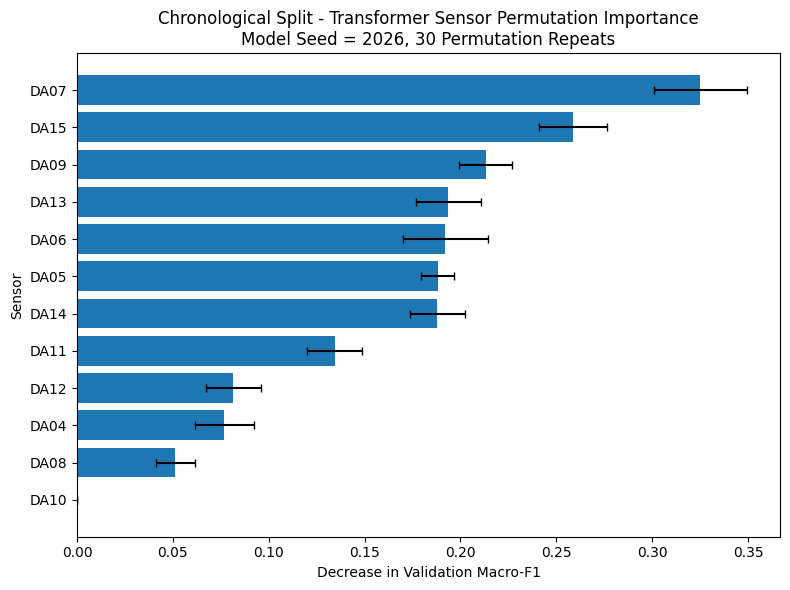

In [110]:
# ============================================================
# Step 11 - Sensor importance plot
# ============================================================

plot_df = importance_summary.sort_values(
    "mean",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["sensor"],
    plot_df["mean"],
    xerr=plot_df["std"],
    capsize=3
)

plt.xlabel("Decrease in Validation Macro-F1")
plt.ylabel("Sensor")
plt.title(
    "Chronological Split - Transformer Sensor Permutation Importance\n"
    f"Model Seed = {MODEL_SEED}, 30 Permutation Repeats"
)

plt.tight_layout()
plt.show()